In [1]:
# import libraries
# JJ

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
# load the data
# JJ

df = pd.read_csv('../data/final_merged_data_v2.csv')

print(f"shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

shape: (2056, 13)
Columns: ['service_date', 'line', 'est_ridership', 'num_slow_zones', 'total_track_pct', 'total_miles_affected', 'otp_score', 'day_of_week', 'month', 'num_alerts', 'has_special_event', 'alert_effect_delay', 'alert_effect_shuttle']


,service_date,line,est_ridership,num_slow_zones,total_track_pct,total_miles_affected,otp_score,day_of_week,month,num_alerts,has_special_event,alert_effect_delay,alert_effect_shuttle
0,2023-01-01,blue,15214.400000,0.0,0.000000,0.000000,0.993762,Sunday,January,0.0,False,0.0,0.0
1,2023-01-01,green,22745.689929,17.0,0.032971,1.780114,0.795319,Sunday,January,0.0,False,0.0,0.0
2,2023-01-01,orange,24492.170000,12.0,0.088899,2.003788,0.978458,Sunday,January,2.0,False,1.0,1.0


In [3]:
# missing value analysis -- no missing values
# JJ

# find missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Percentage of dataset that is missing: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.2f}%")

# show which rows have missing values
if df.isnull().sum().sum() > 0:
    print(f"\nRows with any missing values: {df.isnull().any(axis=1).sum()}")

Missing values per column:
service_date            0
line                    0
est_ridership           0
num_slow_zones          0
total_track_pct         0
total_miles_affected    0
otp_score               0
day_of_week             0
month                   0
num_alerts              0
has_special_event       0
alert_effect_delay      0
alert_effect_shuttle    0
dtype: int64

Total missing values: 0
Percentage of dataset that is missing: 0.00%


In [4]:
# check data types and date ranges
# JJ

print("Data types:")
print(df.dtypes)
print("\nDate range:")
print(f"From: {df['service_date'].min()}")
print(f"To: {df['service_date'].max()}")
print(f"\nUnique lines: {df['line'].unique()}")
print(f"Unique days of week: {df['day_of_week'].unique()}")
print(f"Unique months: {df['month'].unique()}")

Data types:
service_date             object
line                     object
est_ridership           float64
num_slow_zones          float64
total_track_pct         float64
total_miles_affected    float64
otp_score               float64
day_of_week              object
month                    object
num_alerts              float64
has_special_event          bool
alert_effect_delay      float64
alert_effect_shuttle    float64
dtype: object

Date range:
From: 2023-01-01
To: 2024-05-28

Unique lines: ['blue' 'green' 'orange' 'red']
Unique days of week: ['Sunday' 'Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday']
Unique months: ['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August'
 'September' 'October' 'November' 'December']


In [5]:
# sort by line and date
#JJ
df = df.sort_values(['line', 'service_date']).reset_index(drop=True)

print(df[['service_date', 'line', 'est_ridership']].head(5))

  service_date  line  est_ridership
0   2023-01-01  blue        15214.4
1   2023-01-02  blue        19025.4
2   2023-01-03  blue        25893.5
3   2023-01-04  blue        30212.7
4   2023-01-05  blue        30162.3


In [6]:
# review stats & check for skewness
# JJ

# stats
print("Descriptive Statistics:")
numeric_cols = ['est_ridership', 'num_slow_zones', 'total_track_pct', 
                'total_miles_affected', 'otp_score', 'num_alerts',
               'alert_effect_delay', 'alert_effect_shuttle']
stats = df[numeric_cols].describe()
print(stats)

# Check for skewness
print("\nSkewness values:")
for col in numeric_cols:
    skew = df[col].skew()
    print(f"{col}: {skew:.3f}")

Descriptive Statistics:
       est_ridership  num_slow_zones  total_track_pct  total_miles_affected  \
count    2056.000000     2056.000000      2056.000000           2056.000000   
mean    53453.791443       41.697471         0.210322              6.332326   
std     23868.360808       29.552854         0.122029              3.988564   
min      2488.590000        0.000000         0.000000              0.000000   
25%     35146.850000       16.000000         0.166264              3.948011   
50%     47540.791585       35.000000         0.198393              4.580398   
75%     76209.985000       63.000000         0.264520              9.757765   
max    129547.140000      116.000000         0.890523             15.158523   

         otp_score   num_alerts  alert_effect_delay  alert_effect_shuttle  
count  2056.000000  2056.000000         2056.000000           2056.000000  
mean      0.887009     2.154183            1.220331              0.243191  
std       0.077541     2.063484     

In [7]:
# handle skewed variabels
# JJ

# copy of ddd for transformations
df_transformed = df.copy()

# log transformation for highly right-skewed variables
# adding 1 to handle any zero values
df_transformed['num_alerts_log'] = np.log1p(df['num_alerts'])  # log(x+1)
# ALC
df_transformed['alert_effect_delay_log'] = np.log1p(df['alert_effect_delay'])  # log(x+1)
df_transformed['alert_effect_shuttle_log'] = np.log1p(df['alert_effect_shuttle'])  # log(x+1)
df_transformed['total_track_pct_log'] = np.log1p(df['total_track_pct'])
# JJ
# square root transformation for moderately skewed variables
df_transformed['num_slow_zones_sqrt'] = np.sqrt(df['num_slow_zones'])

# check if transformations helped
print("Original vs Transformed Skewness:")
print(f"num_alerts: {df['num_alerts'].skew ():.3f} -> {df_transformed['num_alerts_log'].skew():.3f}")
print(f"num_slow_zones: {df['num_slow_zones'].skew ():.3f} -> {df_transformed['num_slow_zones_sqrt'].skew():.3f}")
# ALC
print(f"alert_effect_delay: {df['alert_effect_delay'].skew ():.3f} -> {df_transformed['alert_effect_delay_log'].skew():.3f}")
print(f"alert_effect_shuttle: {df['alert_effect_shuttle'].skew ():.3f} -> {df_transformed['alert_effect_shuttle_log'].skew():.3f}")
print(f"total_track_pct: {df['total_track_pct'].skew ():.3f} -> {df_transformed['total_track_pct_log'].skew():.3f}")

Original vs Transformed Skewness:
num_alerts: 1.823 -> 0.022
num_slow_zones: 0.782 -> -0.089
alert_effect_delay: 1.204 -> 0.152
alert_effect_shuttle: 3.007 -> 2.140
total_track_pct: 0.969 -> 0.387


In [8]:
# add one hot encoding while keeping original columns
# JJ

categorical_cols = ['line', 'day_of_week', 'month']

for col in categorical_cols:
    print(f"\n{col} unique values: {df_transformed[col].unique()}")

# create dummy variables
df_encoded = pd.get_dummies(df_transformed, columns=categorical_cols, 
                            prefix=categorical_cols, drop_first=False)

print(f"\nOriginal dataset shape: {df_transformed.shape}")
print(f"After one-hot encoding: {df_encoded.shape}")
print(f"\nNew columns added: {df_encoded.shape[1] - df_transformed.shape[1]}")

# show sample of the new columns
new_cols = [col for col in df_encoded.columns if any
            (cat in col for cat in categorical_cols)]
print(f"\nNew categorical columns (first 10): {new_cols[:10]}")


line unique values: ['blue' 'green' 'orange' 'red']

day_of_week unique values: ['Sunday' 'Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday']

month unique values: ['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August'
 'September' 'October' 'November' 'December']

Original dataset shape: (2056, 18)
After one-hot encoding: (2056, 38)

New columns added: 20

New categorical columns (first 10): ['line_blue', 'line_green', 'line_orange', 'line_red', 'day_of_week_Friday', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday']


In [9]:
# create lagged features
# JJ

# sort by line and date to ensure proper order for lag creation
df_encoded = df_encoded.sort_values(['line_blue', 'line_green', 
                                     'line_orange', 'service_date'])

# create lagged features for each line separately
# create 1-day lag and 7-day rolling average

# initialize lag columns
lag_cols = ['otp_score_lag1', 'ridership_lag1', 
            'slow_zones_7day_avg', 'otp_score_7day_avg']
for col in lag_cols:
    df_encoded[col] = np.nan

# create lags for each line
lines = ['blue', 'green', 'orange', 'red']

for line in lines:
    # create mask for current line
    mask = df_encoded[f'line_{line}'] == 1
    
    # get indices for this line (sorted by date)
    line_indices = df_encoded[mask].index
    
    # create lag features
    df_encoded.loc[mask, 'otp_score_lag1'] = df_encoded.loc[
        mask, 'otp_score'].shift(1)
    df_encoded.loc[mask, 'ridership_lag1'] = df_encoded.loc[
        mask, 'est_ridership'].shift(1)
    df_encoded.loc[mask, 'slow_zones_7day_avg'] = df_encoded.loc[
        mask, 'num_slow_zones'].rolling(7, min_periods=1).mean()
    df_encoded.loc[mask, 'otp_score_7day_avg'] = df_encoded.loc[
        mask, 'otp_score'].rolling(7, min_periods=1).mean()

print("Lagged features created!")
print(f"Missing values in lag columns:")
for col in lag_cols:
    missing = df_encoded[col].isnull().sum()
    print(f"{col}: {missing}")

Lagged features created!
Missing values in lag columns:
otp_score_lag1: 4
ridership_lag1: 4
slow_zones_7day_avg: 0
otp_score_7day_avg: 0


In [10]:
# create interaction features
#JJ

# weekend flag
df_encoded['weekend_flag'] = (df_encoded['day_of_week_Saturday'] == 
                              1) | (df_encoded['day_of_week_Sunday'] == 1)

# key interactions for our analysis
df_encoded['slow_zones_x_weekend'] = df_encoded['num_slow_zones_sqrt'] * df_encoded['weekend_flag']
df_encoded['alerts_x_weekend'] = df_encoded['num_alerts_log'] * df_encoded['weekend_flag']
df_encoded['reliability_x_slow_zones'] = df_encoded['otp_score'] * df_encoded['num_slow_zones_sqrt']

# line-specific interactions - how does each line respond to slow zones?
for line in ['blue', 'green', 'orange', 'red']:
    df_encoded[f'slow_zones_x_{line}'] = df_encoded['num_slow_zones_sqrt'] * df_encoded[f'line_{line}']

print(f"New dataset shape: {df_encoded.shape}")

# summary of all our engineered features
engineered_features = ['num_alerts_log', 'num_slow_zones_sqrt', 'weekend_flag', 
                      'slow_zones_x_weekend', 'alerts_x_weekend', 
                       'reliability_x_slow_zones'] + lag_cols
print(f"\nEngineered features: {engineered_features}")

New dataset shape: (2056, 50)

Engineered features: ['num_alerts_log', 'num_slow_zones_sqrt', 'weekend_flag', 'slow_zones_x_weekend', 'alerts_x_weekend', 'reliability_x_slow_zones', 'otp_score_lag1', 'ridership_lag1', 'slow_zones_7day_avg', 'otp_score_7day_avg']


In [11]:
# train/Test Split - using time-based split for time series data
# JJ

# time-based split
split_date = '2024-01-01'
train_mask = df_encoded['service_date'] < split_date
test_mask = df_encoded['service_date'] >= split_date

train_data = df_encoded[train_mask].copy()
test_data = df_encoded[test_mask].copy()

print(f"Training set: {train_data.shape}")
print(f"Test set: {test_data.shape}")
print(f"Split date: {split_date}")
print(f"Training period: {train_data['service_date'].min()} to {train_data['service_date'].max()}")
print(f"Test period: {test_data['service_date'].min()} to {test_data['service_date'].max()}")

Training set: (1460, 50)
Test set: (596, 50)
Split date: 2024-01-01
Training period: 2023-01-01 to 2023-12-31
Test period: 2024-01-01 to 2024-05-28


In [12]:
# PCA on slow zone related features to reduce multicollinearity
# Unsupervised method 1
# JJ -- ALC refactored into a function
def perform_pca(df, test_df, features, pc_name):
    X_pca = df[features].copy()
    X_test_pca = test_df[features].copy()

    print(f"Original correlation matrix:")
    print(X_pca.corr().round(3))

    # standardize the features
    scaler_pca = StandardScaler()
    X_scaled = scaler_pca.fit_transform(X_pca)
    # apply the same fitted scaler to the test set to prevent data leakage
    X_test_scaled = scaler_pca.transform(X_test_pca)

    # apply PCA
    pca = PCA()
    pca_result = pca.fit_transform(X_scaled)
    # fit the same pca model to the test set to prevent data leakage
    pca_test = pca.transform(X_test_scaled)

    # show results
    print(f"\nExplained variance ratio: {pca.explained_variance_ratio_.round(3)}")
    print(f"Cumulative explained variance: {np.cumsum(pca.explained_variance_ratio_).round(3)}")

    # add the first two components to our dataset
    df[f'{pc_name}_pc1'] = pca_result[:, 0]
    df[f'{pc_name}_pc2'] = pca_result[:, 1]
    test_df[f'{pc_name}_pc1'] = pca_test[:, 0]
    test_df[f'{pc_name}_pc2'] = pca_test[:, 1]

    print(f"\nPCA completed! PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance")
    print(f"PC1 + PC2 together explain {np.cumsum(pca.explained_variance_ratio_)[1]:.1%} of variance")
    
    return df, test_df

In [13]:
# PCA on slow zone related features to reduce multicollinearity
# Unsupervised method 1
# JJ
# ALC refactor

# select slow zone features for PCA
slow_zone_features = ['num_slow_zones', 'total_track_pct', 'total_miles_affected']
# ALC
pc_name = 'infrastructure_stress'
print("Training set: \n")
train_data, test_data = perform_pca(train_data, test_data, slow_zone_features, pc_name)

Training set: 

Original correlation matrix:
                      num_slow_zones  total_track_pct  total_miles_affected
num_slow_zones                 1.000            0.100                 0.924
total_track_pct                0.100            1.000                 0.352
total_miles_affected           0.924            0.352                 1.000

Explained variance ratio: [0.675 0.311 0.014]
Cumulative explained variance: [0.675 0.986 1.   ]

PCA completed! PC1 explains 67.5% of variance
PC1 + PC2 together explain 98.6% of variance


In [14]:
# PCA again
# ALC
alert_features = ['num_alerts', 'alert_effect_delay', 'alert_effect_shuttle']
pc_name = 'inconvenience'
print("Training set: \n")
train_data, test_data = perform_pca(train_data, test_data, alert_features, pc_name)

Training set: 

Original correlation matrix:
                      num_alerts  alert_effect_delay  alert_effect_shuttle
num_alerts                 1.000               0.812                 0.502
alert_effect_delay         0.812               1.000                 0.234
alert_effect_shuttle       0.502               0.234                 1.000

Explained variance ratio: [0.69  0.265 0.046]
Cumulative explained variance: [0.69  0.954 1.   ]

PCA completed! PC1 explains 69.0% of variance
PC1 + PC2 together explain 95.4% of variance


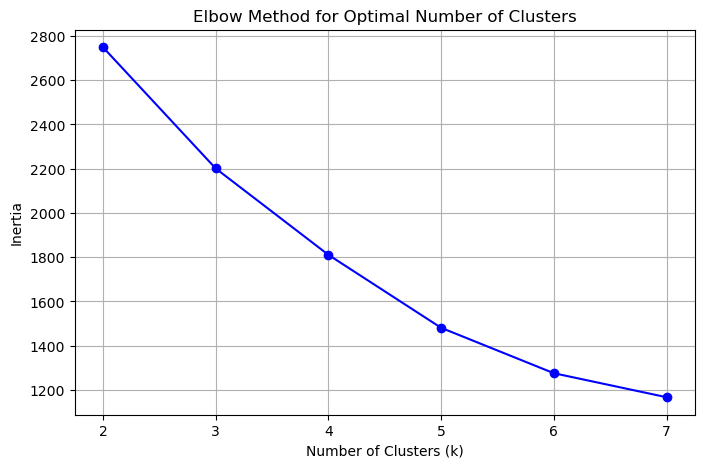

Inertias by k: {2: 2749.215556456938, 3: 2201.341076113865, 4: 1810.8271859854704, 5: 1480.981909601221, 6: 1275.7999729184203, 7: 1167.306414222803}


In [15]:
# K-means clustering to identify different service quality patterns
# Unsupervised method 2
#JJ -- ALC modified to fit only on training set
# select features for clustering
cluster_features = ['otp_score', 'num_slow_zones', 
                    'num_alerts', 'infrastructure_stress_pc1']
X_cluster = train_data[cluster_features].copy()
X_cluster_test = test_data[cluster_features].copy()

# handle any missing values (from lag features)
X_cluster = X_cluster.fillna(X_cluster.mean())
# using training mean
X_cluster_test = X_cluster_test.fillna(X_cluster.mean())

# standardize for clustering
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)
X_cluster_scaled_test = scaler_cluster.transform(X_cluster_test)

# find optimal number of clusters -- using elbow method
inertias = []
k_range = range(2, 8)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)

# plot curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

print("Inertias by k:", dict(zip(k_range, inertias)))

In [16]:
# apply K-means with the available features
# JJ -- ALC edited to only apply fit to train
X_cluster = train_data[cluster_features].copy()
X_cluster_test = test_data[cluster_features].copy()
X_cluster = X_cluster.fillna(X_cluster.mean())
# fill with training mean
X_cluster_test = X_cluster_test.fillna(X_cluster.mean())

# scale data, and scale test data based on training data scaler fit
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)
X_cluster_scaled_test = scaler_cluster.transform(X_cluster_test)

optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
train_data['service_quality_cluster'] = kmeans_final.fit_predict(X_cluster_scaled)
# predict test data based on training data fit
test_data['service_quality_cluster'] = kmeans_final.predict(X_cluster_scaled_test)

print(f"Clustering completed with k={optimal_k}")
print(f"Cluster distribution:")
print(train_data['service_quality_cluster'].value_counts().sort_index())

# analyze what each cluster represents
print(f"\nCluster characteristics:")
cluster_summary = train_data.groupby('service_quality_cluster')[cluster_features].mean()
print(cluster_summary.round(3))

# interpretation
print(f"\nCluster interpretation:")
for i in range(optimal_k):
    cluster_data = cluster_summary.iloc[i]
    print(f"Cluster {i}: OTP={cluster_data['otp_score']:.3f}, Slow Zones={cluster_data['num_slow_zones']:.1f}, Alerts={cluster_data['num_alerts']:.1f}")

Clustering completed with k=3
Cluster distribution:
service_quality_cluster
0    886
1    336
2    238
Name: count, dtype: int64

Cluster characteristics:
                         otp_score  num_slow_zones  num_alerts  \
service_quality_cluster                                          
0                            0.916          24.172       1.253   
1                            0.773          68.938       3.604   
2                            0.906          98.076       3.437   

                         infrastructure_stress_pc1  
service_quality_cluster                             
0                                           -0.969  
1                                            1.088  
2                                            2.070  

Cluster interpretation:
Cluster 0: OTP=0.916, Slow Zones=24.2, Alerts=1.3
Cluster 1: OTP=0.773, Slow Zones=68.9, Alerts=3.6
Cluster 2: OTP=0.906, Slow Zones=98.1, Alerts=3.4


In [17]:
# train/Test Split - using time-based split for time series data
# JJ

# check cluster distribution in train vs test
print(f"\nCluster distribution in training data:")
print(train_data['service_quality_cluster'].value_counts().sort_index())
print(f"\nCluster distribution in test data:")
print(test_data['service_quality_cluster'].value_counts().sort_index())


Cluster distribution in training data:
service_quality_cluster
0    886
1    336
2    238
Name: count, dtype: int64

Cluster distribution in test data:
service_quality_cluster
0    528
1     57
2     11
Name: count, dtype: int64


In [18]:
# ALC
# one hot encode these because they are categories not continuous
train_data = pd.get_dummies(train_data, columns=['service_quality_cluster'], 
                            prefix=['service_quality_cluster'], drop_first=False)
test_data = pd.get_dummies(test_data, columns=['service_quality_cluster'], 
                            prefix=['service_quality_cluster'], drop_first=False)

# create csv we can use
train_data.to_csv("../data/training_data_v2.csv", index = False)
test_data.to_csv("../data/test_data_v2.csv", index = False)

In [19]:
# save the datasets
#JJ

#train_data.to_csv('../data/train_data_preprocessed.csv', index=False)
#test_data.to_csv('../data/test_data_preprocessed.csv', index=False)
#df_encoded.to_csv('../data/full_preprocessed_data.csv', index=False)

print(f"Original dataset: {df.shape[1]} columns")
print(f"Final dataset: {train_data.shape[1]} columns") 

Original dataset: 13 columns
Final dataset: 57 columns
